Now, we apply the best-performing model (GPT-5) on the training part of the X-GENRE dataset.

In [ ]:
import pandas as pd
import json
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from time import sleep
from openai import OpenAI
from tqdm import tqdm
client = OpenAI(api_key=open('key.txt').read())

In [3]:
# Open the X-GENRE train dataset
from datasets import load_dataset
import pandas as pd

train = load_dataset("TajaKuzmanPungersek/X-GENRE-text-genre-dataset", "train")

# To open as Pandas DataFrame:
train_df = pd.DataFrame(train["train"])

Generating train split: 100%|██████████| 1772/1772 [00:00<00:00, 19113.80 examples/s]


In [4]:
train_df.head(2)

,text,labels,dataset,language
0,"Seeking All Things Brilliant ""I want people to...",Other,CORE,English
1,Meet Orchid du Bois I first met Hayley Mowday ...,Other,CORE,English


In [5]:
def length(text):
	length = len(text.split())
	return length

train_df["length"] = train_df["text"].apply(length)

display(train_df.head())

train_df["length"].describe()

,text,labels,dataset,language,length
0,"Seeking All Things Brilliant ""I want people to...",Other,CORE,English,1310
1,Meet Orchid du Bois I first met Hayley Mowday ...,Other,CORE,English,1429
2,Abstract Objective: Reporting bias due to soci...,Information/Explanation,CORE,English,4610
3,In 2009 the song was the focus of a successful...,Information/Explanation,CORE,English,2391
4,QuotW This was the week when neither rumours o...,News,CORE,English,706


count      1772.000000
mean       1094.987020
std        3951.692792
min          17.000000
25%         172.000000
50%         390.000000
75%         923.750000
max      102457.000000
Name: length, dtype: float64

In [7]:
train_df["ID"] = train_df.index
train_df.head(2)

,text,labels,dataset,language,length,ID
0,"Seeking All Things Brilliant ""I want people to...",Other,CORE,English,1310,0
1,Meet Orchid du Bois I first met Hayley Mowday ...,Other,CORE,English,1429,1


In [6]:
train_df.labels.value_counts()

labels
News                       344
Information/Explanation    306
Promotion                  287
Opinion/Argumentation      242
Instruction                210
Forum                      140
Prose/Lyrical              109
Other                       70
Legal                       64
Name: count, dtype: int64

In [56]:
labels_list=['Other', 'Information/Explanation', 'News', 'Instruction', 'Opinion/Argumentation', 'Forum', 'Prose/Lyrical', 'Legal', 'Promotion']

labels_dict = {
	0: "Other",
	1: "Information/Explanation",
	2: "News",
	3: "Instruction",
	4: "Opinion/Argumentation",
	5: "Forum",
	6: "Prose/Lyrical",
	7: "Legal",
	8: "Promotion"
}

Let's use the batching option

In [23]:
def batch_file(df, gpt_model):

	instances = []
	
	texts = df["text"].to_list()
	indices = df["ID"].to_list()

	label_dict_with_description_ext = {
			"Information/Explanation - An objective text that describes or presents an event, a person, a thing, a concept etc. Its main purpose is to inform the reader about something. Common features: objective/factual, explanation/definition of a concept (x is …), enumeration. E.g., research article, encyclopedia article, informational blog, product specification, course materials, general information, job description, manual, horoscope, travel guide, glossaries, historical article, biographical story/history.": 1,
			"News - An objective or subjective text which reports on an event recent at the time of writing or coming in the near future. Common features: adverbs/adverbial clauses of time and/or place (dates, places), many proper nouns, direct or reported speech, past tense. E.g., news report, sports report, travel blog, reportage, police report, announcement.": 2,
			"Instruction - An objective text which instructs the readers on how to do something. Common features: multiple steps/actions, chronological order, 1st person plural or 2nd person, modality (must, have to, need to, can, etc.), adverbial clauses of manner (in a way that), of condition (if), of time (after …). E.g., how-to texts, recipes, technical support.": 3,
			"Opinion/Argumentation - A subjective text in which the authors convey their opinion or narrate their experience. It includes promotion of an ideology and other non-commercial causes. This genre includes a subjective narration of a personal experience as well. Common features: adjectives/adverbs that convey opinion, words that convey (un)certainty (certainly, surely), 1st person, exclamation marks. E.g., review, blog (personal blog, travel blog), editorial, advice, letter to editor, persuasive article or essay, formal speech, pamphlet, political propaganda, columns, political manifesto.": 4,
			"Forum - A text in which people discuss a certain topic in form of comments. Common features: multiple authors, informal language, subjective (the writers express their opinions), written in 1st person. E.g., discussion forum, reader/viewer responses, QA forum.": 5,
			"Prose/Lyrical - A literary text that consists of paragraphs or verses. A literary text is deemed to have no other practical purpose than to give pleasure to the reader. Often the author pays attention to the aesthetic appearance of the text. It can be considered as art. E.g., lyrics, poem, prayer, joke, novel, short story. ": 6,
			"Legal - An objective formal text that contains legal terms and is clearly structured. The name of the text type is often included in the headline (contract, rules, amendment, general terms and conditions, etc.). Common features: objective/factual, legal terms, 3rd person. E.g., small print, software license, proclamation, terms and conditions, contracts, law, copyright notices, university regulation.": 7,
			"Promotion - A subjective text intended to sell or promote an event, product, or service. It addresses the readers, often trying to convince them to participate in something or buy something. Common features: contains adjectives/adverbs that promote something (high-quality, perfect, amazing), comparative and superlative forms of adjectives and adverbs (the best, the greatest, the cheapest), addressing the reader (usage of 2nd person), exclamation marks. E.g., advertisement, promotion of a product (e-shops), promotion of an accommodation, promotion of company's services, invitation to an event.": 8,
			"Other - A text that which does not fall under any of other genre categories.": 0,

	}


	for x in list(zip(texts, indices)):
		text = x[0]
		index = str(x[1])
		cur_prompt = {"custom_id": index, "method": "POST", "url": "/v1/chat/completions", "body":
			{"model": gpt_model,
			"response_format": {"type": "json_object"},
	 		"messages": [
				{
				"role": "user",
	 			"content": f"""
				### Task
				Your task is to classify the following text according to genre. Genres are text types, defined by the function of the text, author’s purpose and form of the text. Always provide a label, even if you are not sure.

				### Output format
					Return a valid JSON dictionary with the following key: 'genre' and a value should be an integer which represents one of the labels according to the following dictionary: {label_dict_with_description_ext}.

					
					Text: '{text}'
			"""
				},
				]
			}
		}

		instances.append(cur_prompt)
	
	return instances

In [24]:
instances = batch_file(train_df, "gpt-5-2025-08-07")

# Save the batch file as a jsonl
with open("datasets/x-genre-annotation-batch.jsonl", "w") as f:
    for item in instances:
        f.write(json.dumps(item))
        f.write("\n")

In [25]:
# Upload the batch file
batch_input_file = client.files.create(
    file=open("datasets/x-genre-annotation-batch.jsonl", "rb"),
    purpose="batch"
)

print(batch_input_file)

FileObject(id='file-SYi16HRamscxg9mqjqt6jv', bytes=18525820, created_at=1765193476, filename='x-genre-annotation-batch.jsonl', object='file', purpose='batch', status='processed', status_details=None, expires_at=1767785476)


In [26]:
# Create the batch
batch_input_file_id = batch_input_file.id
client.batches.create(
    input_file_id=batch_input_file_id,
    endpoint="/v1/chat/completions",
    completion_window="24h",
    metadata={
        "description": "Annotation of the X-GENRE training dataset with GPT-5."
    }
)

Batch(id='batch_6936b738cea48190ab0deae567c12090', completion_window='24h', created_at=1765193528, endpoint='/v1/chat/completions', input_file_id='file-SYi16HRamscxg9mqjqt6jv', object='batch', status='validating', cancelled_at=None, cancelling_at=None, completed_at=None, error_file_id=None, errors=None, expired_at=None, expires_at=1765279928, failed_at=None, finalizing_at=None, in_progress_at=None, metadata={'description': 'Annotation of the X-GENRE training dataset with GPT-5.'}, output_file_id=None, request_counts=BatchRequestCounts(completed=0, failed=0, total=0), model=None, usage={'input_tokens': 0, 'output_tokens': 0, 'total_tokens': 0, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens_details': {'reasoning_tokens': 0}})

In [28]:
batch = client.batches.retrieve("batch_6936b738cea48190ab0deae567c12090")
batch

Batch(id='batch_6936b738cea48190ab0deae567c12090', completion_window='24h', created_at=1765193528, endpoint='/v1/chat/completions', input_file_id='file-SYi16HRamscxg9mqjqt6jv', object='batch', status='in_progress', cancelled_at=None, cancelling_at=None, completed_at=None, error_file_id=None, errors=None, expired_at=None, expires_at=1765279928, failed_at=None, finalizing_at=None, in_progress_at=1765193531, metadata={'description': 'Annotation of the X-GENRE training dataset with GPT-5.'}, output_file_id=None, request_counts=BatchRequestCounts(completed=0, failed=0, total=1772), model='gpt-5-2025-08-07', usage={'input_tokens': 0, 'output_tokens': 0, 'total_tokens': 0, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens_details': {'reasoning_tokens': 0}})

In [29]:
# Check the progress
import time

while True:
    batch = client.batches.retrieve("batch_6936b738cea48190ab0deae567c12090")
    status = batch.status
    progress = batch.request_counts

    print("Status:", status)
    print("Progress:", progress)

    if status == "completed":
        print("Batch completed. Exiting.")
        break

    time.sleep(5 * 60)   # wait 5 minutes

Status: in_progress
Progress: BatchRequestCounts(completed=0, failed=0, total=1772)
Status: in_progress
Progress: BatchRequestCounts(completed=1766, failed=0, total=1772)
Status: in_progress
Progress: BatchRequestCounts(completed=1766, failed=0, total=1772)
Status: in_progress
Progress: BatchRequestCounts(completed=1766, failed=0, total=1772)
Status: completed
Progress: BatchRequestCounts(completed=1772, failed=0, total=1772)
Batch completed. Exiting.


Annotation took 20 minutes with the batch option and cost 4$.

In [ ]:
# Get the output files
batch = client.batches.retrieve("batch_6936b738cea48190ab0deae567c12090")
file_id = batch.output_file_id

file_response = client.files.content(file_id)

# Save this as a file
with open("datasets/x-genre-annotation-batch-annotated_batch_temp.jsonl", "w") as temp_file:
	temp_file.write(file_response.text)

In [ ]:
# Parse the output
def parse_output(jsonl_file):
	outputs = []

	with open(jsonl_file, "r") as f:
		for line in f:
			outputs.append(json.loads(line))
	
	responses = {}

	for output in outputs:
		cur_id = int(output["custom_id"])
		response = output["response"]["body"]["choices"][0]["message"]["content"]

		response = response.replace("\n", "")
		response = response.replace("\t", "")

		# Get out a label
		try:
			# Convert the string into a dictionary
			response = json.loads(response)
			predicted = labels_dict[response["genre"]]
			responses[cur_id] = predicted
		# add a possibility of something going wrong
		except:
			print("error with extracting a label")
			responses[cur_id] = response

	return responses

In [57]:
responses = parse_output("datasets/x-genre-annotation-batch-annotated_batch_temp.jsonl")
responses

{0: 'Opinion/Argumentation',
 1: 'News',
 2: 'Information/Explanation',
 3: 'Information/Explanation',
 4: 'News',
 5: 'News',
 6: 'Instruction',
 7: 'Instruction',
 8: 'Opinion/Argumentation',
 9: 'News',
 10: 'Forum',
 11: 'News',
 12: 'Opinion/Argumentation',
 13: 'Forum',
 14: 'Prose/Lyrical',
 15: 'Forum',
 16: 'Forum',
 17: 'Forum',
 18: 'News',
 19: 'News',
 20: 'Forum',
 21: 'News',
 22: 'Information/Explanation',
 23: 'News',
 24: 'Forum',
 25: 'Opinion/Argumentation',
 26: 'News',
 27: 'Forum',
 28: 'Forum',
 29: 'Prose/Lyrical',
 30: 'Forum',
 31: 'News',
 32: 'Opinion/Argumentation',
 33: 'Instruction',
 34: 'News',
 35: 'Legal',
 36: 'News',
 37: 'Instruction',
 38: 'Forum',
 39: 'Information/Explanation',
 40: 'Instruction',
 41: 'Forum',
 42: 'Opinion/Argumentation',
 43: 'Forum',
 44: 'Opinion/Argumentation',
 45: 'Forum',
 46: 'Opinion/Argumentation',
 47: 'Forum',
 48: 'Forum',
 49: 'Instruction',
 50: 'Information/Explanation',
 51: 'Forum',
 52: 'Instruction',
 53: 

In [61]:
responses_df = pd.DataFrame({"ID": list(responses.keys()), "LLM_label": list(responses.values()) })
responses_df

,ID,LLM_label
0,0,Opinion/Argumentation
1,1,News
2,2,Information/Explanation
3,3,Information/Explanation
4,4,News
...,...,...
1767,1767,Promotion
1768,1768,Information/Explanation
1769,1769,Opinion/Argumentation
1770,1770,Prose/Lyrical


In [63]:
# Add the output to the X-GENRE dataset
final_df = pd.merge(left=train_df, right=responses_df, on="ID")
final_df.head(5)

,text,labels,dataset,language,length,ID,LLM_label
0,"Seeking All Things Brilliant ""I want people to...",Other,CORE,English,1310,0,Opinion/Argumentation
1,Meet Orchid du Bois I first met Hayley Mowday ...,Other,CORE,English,1429,1,News
2,Abstract Objective: Reporting bias due to soci...,Information/Explanation,CORE,English,4610,2,Information/Explanation
3,In 2009 the song was the focus of a successful...,Information/Explanation,CORE,English,2391,3,Information/Explanation
4,QuotW This was the week when neither rumours o...,News,CORE,English,706,4,News


In [64]:
final_df["labels"].value_counts()

labels
News                       344
Information/Explanation    306
Promotion                  287
Opinion/Argumentation      242
Instruction                210
Forum                      140
Prose/Lyrical              109
Other                       70
Legal                       64
Name: count, dtype: int64

In [65]:
final_df["LLM_label"].value_counts()

LLM_label
News                       371
Information/Explanation    364
Promotion                  261
Opinion/Argumentation      252
Forum                      188
Instruction                162
Prose/Lyrical              110
Legal                       62
Other                        2
Name: count, dtype: int64

In [66]:
# Save the dataset
final_df.to_json("datasets/X-GENRE-train-with-LLM-predictions.jsonl", orient="records", lines=True)

In [67]:
# Evaluate the model against manually-annotated instances
def evaluate(df, y_true_column, y_test_column, matrix=True):
	# Evaluate the performance of the model
	from sklearn.metrics import f1_score
	import matplotlib.pyplot as plt
	from sklearn.metrics import confusion_matrix, classification_report

	# Get the true labels
	y_true = df[y_true_column].to_list()
	LABELS = list(df[y_true_column].unique())
	y_pred = df[y_test_column].to_list()

	# Calculate the scores
	macro = f1_score(y_true, y_pred, labels=LABELS, average="macro")
	micro = f1_score(y_true, y_pred, labels=LABELS,  average="micro")
	print(f"Macro f1: {macro:0.3}, Micro f1: {micro:0.3}")

	scores = {"micro_F1": micro, "macro_F1": macro}

	print(classification_report(y_true, y_pred))

	if matrix == True:
		# Plot the confusion matrix:
		cm = confusion_matrix(y_true, y_pred, labels=LABELS)
		plt.figure(figsize=(9, 9))
		plt.imshow(cm, cmap="Oranges")
		for (i, j), z in np.ndenumerate(cm):
			plt.text(j, i, '{:d}'.format(z), ha='center', va='center')
		classNames = LABELS
		plt.ylabel('True label')
		plt.xlabel('Predicted label')
		tick_marks = np.arange(len(classNames))
		plt.xticks(tick_marks, classNames, rotation=90)
		plt.yticks(tick_marks, classNames)
		#plt.title(f"{model_name}")

		plt.tight_layout()
		fig1 = plt.gcf()
		plt.show()
		plt.draw()
	return scores

Macro f1: 0.706, Micro f1: 0.761
                         precision    recall  f1-score   support

                  Forum       0.66      0.89      0.76       140
Information/Explanation       0.71      0.84      0.77       306
            Instruction       0.93      0.71      0.81       210
                  Legal       0.89      0.86      0.87        64
                   News       0.76      0.82      0.79       344
  Opinion/Argumentation       0.65      0.68      0.66       242
                  Other       0.00      0.00      0.00        70
              Promotion       0.82      0.75      0.78       287
          Prose/Lyrical       0.90      0.91      0.90       109

               accuracy                           0.76      1772
              macro avg       0.70      0.72      0.71      1772
           weighted avg       0.74      0.76      0.75      1772



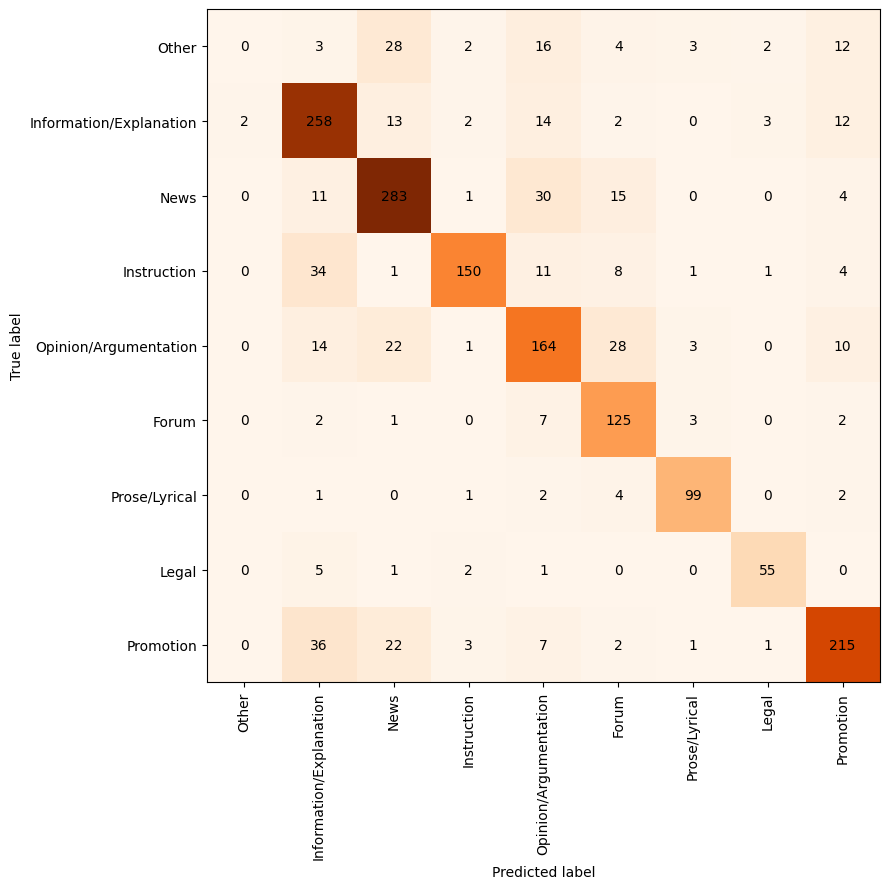

{'micro_F1': 0.7612866817155757, 'macro_F1': 0.7062409984926552}

<Figure size 640x480 with 0 Axes>

In [68]:
evaluate(final_df, "labels", "LLM_label")

Macro f1: 0.809, Micro f1: 0.793
                         precision    recall  f1-score   support

                  Forum       0.68      0.89      0.77       140
Information/Explanation       0.71      0.84      0.77       306
            Instruction       0.94      0.71      0.81       210
                  Legal       0.92      0.86      0.89        64
                   News       0.83      0.82      0.82       344
  Opinion/Argumentation       0.69      0.68      0.69       242
                  Other       0.00      0.00      0.00         0
              Promotion       0.86      0.75      0.80       287
          Prose/Lyrical       0.93      0.91      0.92       109

               accuracy                           0.79      1702
              macro avg       0.73      0.72      0.72      1702
           weighted avg       0.80      0.79      0.79      1702



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

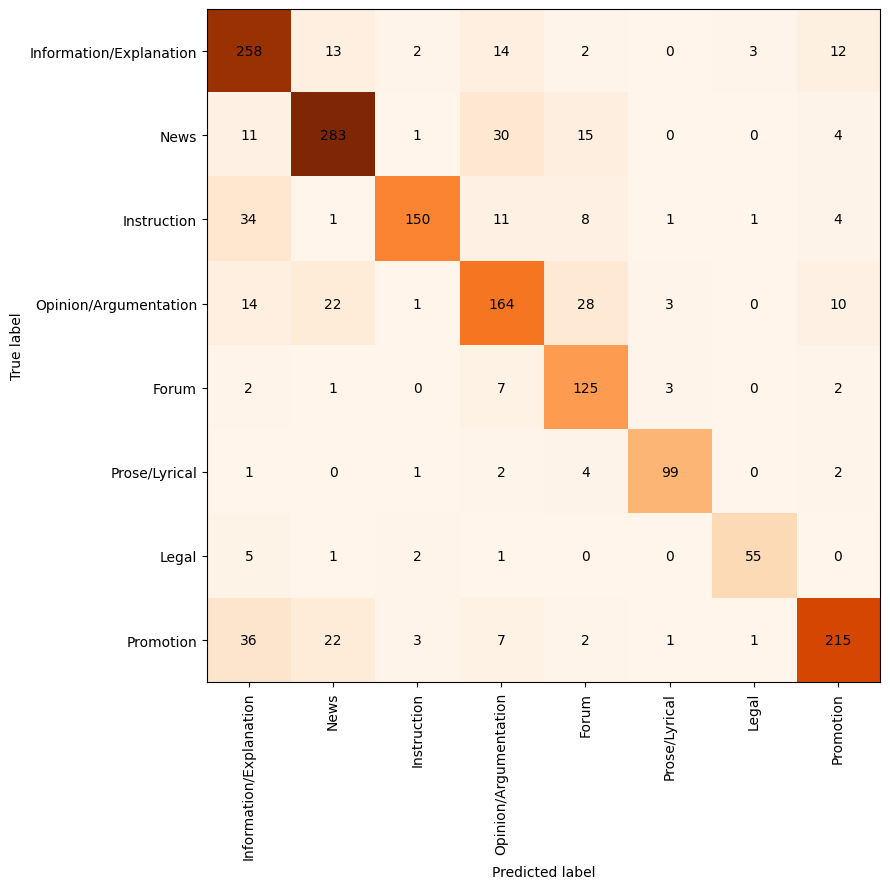

{'micro_F1': 0.7930629041740153, 'macro_F1': 0.8090119455970831}

<Figure size 640x480 with 0 Axes>

In [69]:
# Performance if we remove "Other"

evaluate(final_df[final_df["labels"] != "Other"], "labels", "LLM_label")